# Citi Bike: choose the local candidate

**Contribution owner: Tomislav Novosel.** Implementation, experiments and initial explanations were prepared with AI assistance on 9 October 2026. Human review and substantive changes should be recorded when they happen; see [the assistance record](../docs/AI_USE.md).

These are development experiments, not final-test results. The training/tuning dates end in June; July-September is development validation. October-December has not been scored.

The searches were executed with the helper scripts and their actual reports are saved. By default this notebook reviews those reports quickly. Set `CITIBIKE_RETRAIN=1` or use the runner's `--train` option to execute the search again. The XGBoost search needs a CUDA GPU; viewing results and running the saved app do not.


All rows use the same July-September one-day validation dates. Hyperparameters were searched on earlier training folds. We choose MAE first, with RMSE and bias explaining the trade-offs.

In [17]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd()
while not (ROOT / 'src/citibike_forecast.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open the notebook inside the repository.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
import numpy as np
from citibike_forecast import REPORTS, MODELS, development_data, chronological_cv
RUN_TRAINING = os.environ.get('CITIBIKE_RETRAIN') == '1'
def report(name):
    return json.loads((REPORTS / (name + '_run.json')).read_text(encoding='utf8'))
print('Mode:', 'execute training' if RUN_TRAINING else 'review actual saved experiments')
from citibike_forecast import select_candidate, comparison
if RUN_TRAINING:
    select_candidate()
table = comparison()
main = table[~table.model.str.contains('_ablation')]
display(main.round(4))
candidate = json.loads((REPORTS / 'candidate.json').read_text())
display(pd.Series(candidate))


Mode: review actual saved experiments


,model,mae,rmse,wape,bias,days,cv_mean_mae,mae_improvement_over_lag_7
0,xgboost_tuned,14692.6523,23426.3939,0.1218,3763.6239,92,14058.1794,0.2048
2,random_forest_tuned,15007.2385,23229.0365,0.1244,2332.1394,92,14092.0908,0.1878
3,seasonal_average_tuned,16188.7024,23247.7619,0.1342,1360.3814,92,14545.4438,0.1238
5,mean_7,17716.4627,24812.6875,0.1469,1366.4410,92,14074.7234,0.0412
6,ridge_reference,17850.3345,23119.4764,0.1480,-6392.4756,92,11604.7820,0.0339
7,ridge_tuned,17850.3345,23119.4764,0.1480,-6392.4756,92,11604.7820,0.0339
8,lag_1,17914.9783,27065.5921,0.1485,114.1957,92,13420.7937,0.0304
9,lag_7,18476.9022,28229.7793,0.1532,2869.0978,92,17771.5397,0.0000
10,automl,22331.2127,26534.9804,0.1852,-11451.1694,92,13506.2742,-0.2086
11,training_mean,37173.4500,40428.7090,0.3082,-31344.8684,92,34955.9675,-1.0119


name                                                         xgboost_tuned
status                   Local development candidate; AWS comparison an...
contract_version                                      citibike-next-day-v1
daily_sha256             5a129beca835f620c98c583d1367802aef57d3c6cf46e7...
training_start                                                  2023-01-29
training_end                                                    2023-09-30
training_rows                                                          245
forecast_horizon_days                                                    1
history_days                                                            28
feature_columns          [weekday_sin, weekday_cos, year_sin, year_cos,...
environment              {'python': '3.12.10', 'packages': {'numpy': '2...
metric_scope             July-September rolling one-day development val...
metrics                  {'mae': 14692.65230129076, 'rmse': 23426.39386...
final_test_evaluated     

The local candidate is XGBoost: about 20.5% less MAE than last week, 9.2% less than the stronger seasonal average, and 2.1% less than random forest. These are point comparisons on development validation. The final test and AWS comparison are still open.

No event loop hook running.


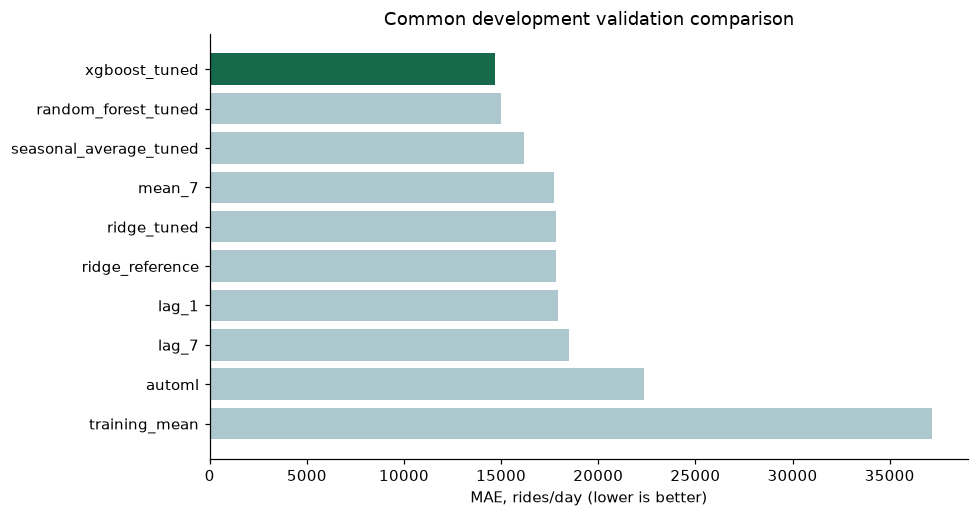

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
FIGURES = ROOT / 'citibike/figures'
fig, ax = plt.subplots(figsize=(9,4.8))
plot = main.sort_values('mae',ascending=False)
ax.barh(plot.model,plot.mae,color=['#17694c' if name=='xgboost_tuned' else '#adc7ce' for name in plot.model])
ax.set(xlabel='MAE, rides/day (lower is better)',title='Common development validation comparison')
fig.tight_layout(); fig.savefig(FIGURES / 'forecast_comparison.png',dpi=150); plt.show()


The chosen configuration is refitted on all 245 eligible January-September development dates. The app bundle contains its full feature contract and metadata; no final-test performance is attached.

In [19]:
print('Training dates:',candidate['training_start'],'through',candidate['training_end'])
print('Final test evaluated:',candidate['final_test_evaluated'])
print('Next: run the AWS candidate, freeze all final choices, then evaluate October-December once.')


Training dates: 2023-01-29 through 2023-09-30
Final test evaluated: False
Next: run the AWS candidate, freeze all final choices, then evaluate October-December once.
